In [1]:
#批归一化
# 统一部分
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline  
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print(sys.version_info)
    
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

print(len(train_dataset))
print(len(test_dataset))

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(class_names)
print(len(class_names))

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,num_workers=4)

sys.version_info(major=3, minor=13, micro=5, releaselevel='final', serial=0)
cuda:0
60000
10000
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
10


In [13]:
#DNN建立

import torch.nn as nn
import torch.nn.functional as F

class DNN(nn.Module):
    def __init__(self, input_size = 784, hidden_size = 256, output_size = 10, num_hidden_layers = 19, num_classes = 10):
        super(DNN, self).__init__()

        layers = []
        
        #第一隐藏层
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(p=0.2))
        
        # 隐藏层
        for i in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())
        
        # 输出层
        layers.append(nn.Linear(hidden_size, num_classes))
        
        self.linear_relu_stack = nn.Sequential(*layers)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.linear_relu_stack(x)
        return x
    
model = DNN(input_size = 784, hidden_size = 256, output_size = 10, num_hidden_layers = 19, num_classes = 10)

print(model)
print(sum(p.numel() for p in model.parameters()))

DNN(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=256, bias=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=256, bias=True)
    (8): ReLU()
    (9): Linear(in_features=256, out_features=256, bias=True)
    (10): ReLU()
    (11): Linear(in_features=256, out_features=256, bias=True)
    (12): ReLU()
    (13): Linear(in_features=256, out_features=256, bias=True)
    (14): ReLU()
    (15): Linear(in_features=256, out_features=256, bias=True)
    (16): ReLU()
    (17): Linear(in_features=256, out_features=256, bias=True)
    (18): ReLU()
    (19): Linear(in_features=256, out_features=256, bias=True)
    (20): ReLU()
    (21): Linear(in_features=256, out_features=256, bias=True)
    (22): ReLU()
    (23): Linear(in_features=256, out_features=256

In [14]:
batch_size = 64
input_tensor = torch.randn(batch_size, 1, 28, 28)

print(input_tensor.shape)

with torch.no_grad():
    output = model(input_tensor)

print(output.shape)

assert output.shape == (batch_size, 10), f"期望输出形状为 ({batch_size}, 10), 但得到 {output.shape}"
print("测试通过")

for batch in train_loader:
    inputs, targets = batch
    print(inputs.shape)
    print(targets.shape)
    break

torch.Size([64, 1, 28, 28])
torch.Size([64, 10])
测试通过
torch.Size([64, 1, 28, 28])
torch.Size([64])


In [ ]:
from my_trainer_for_t1 import Trainer

device = torch.device("cuda")
print(f"使用设备: {device}")

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

early_stopping_kwargs = {
    'patience': 10,
    'min_delta': 0.001,
    'mode': 'max'
}

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=500,
    # early_stopping_kwargs=early_stopping_kwargs
)

trainer.train(num_epochs=20)

使用设备: cuda
[Step 500] Val Loss: 2.3012 Val Acc: 0.1135
Epoch [1/20]  Train Loss: 2.2443  Train Acc: 0.1274
[Step 1000] Val Loss: 1.5353 Val Acc: 0.3406
[Step 1500] Val Loss: 1.1508 Val Acc: 0.5459
Epoch [2/20]  Train Loss: 1.2697  Train Acc: 0.4998
[Step 2000] Val Loss: 0.9251 Val Acc: 0.6640
[Step 2500] Val Loss: 0.6424 Val Acc: 0.7959
Epoch [3/20]  Train Loss: 0.7915  Train Acc: 0.7330
[Step 3000] Val Loss: 0.7298 Val Acc: 0.7507
[Step 3500] Val Loss: 0.6175 Val Acc: 0.8088
Epoch [4/20]  Train Loss: 0.6554  Train Acc: 0.7810
[Step 4000] Val Loss: 0.5530 Val Acc: 0.8395
[Step 4500] Val Loss: 0.6093 Val Acc: 0.8435
Epoch [5/20]  Train Loss: 0.5884  Train Acc: 0.8257
[Step 5000] Val Loss: 0.6077 Val Acc: 0.8380
[Step 5500] Val Loss: 0.9661 Val Acc: 0.6627
Epoch [6/20]  Train Loss: 0.9069  Train Acc: 0.6992
[Step 6000] Val Loss: 1.1035 Val Acc: 0.6038
[Step 6500] Val Loss: 0.6658 Val Acc: 0.8005
Epoch [7/20]  Train Loss: 0.9956  Train Acc: 0.6553
[Step 7000] Val Loss: 0.6884 Val Acc: 0.7

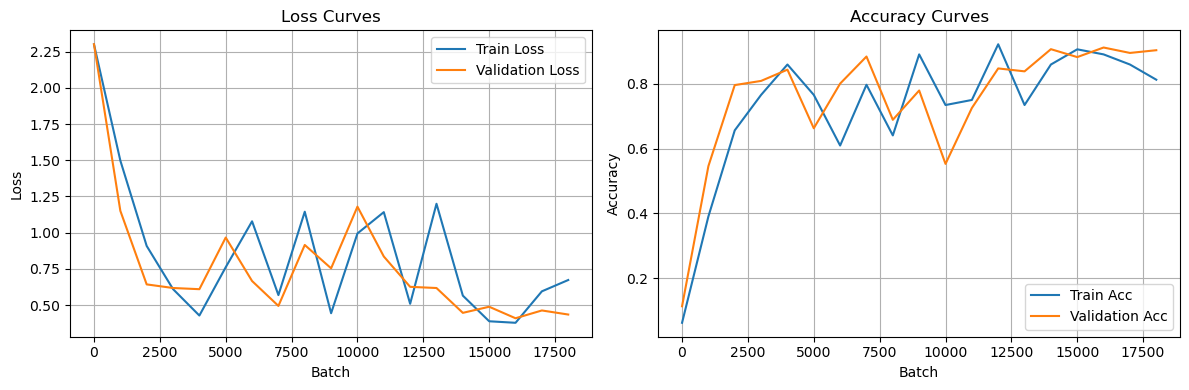

In [16]:
trainer.plot_curves()